# Pokemon Stat Baseline Models

Goal: build a simple baseline model to predict `p1_wins` from pre-battle team Pokemon stats only. This notebook intentionally excludes Elo, Pokemon types, moves, abilities, items, and appeared-in-battle features. Using only the pokemon showed up might introduce bias to the model.

Feature groups included:

- Aggregate stat differences: p1 team mean/min/max minus p2 team mean/min/max.
- Individual-stat distribution differences: for each stat, sort each team's six values from high to low, then compare rank 1 vs rank 1, rank 2 vs rank 2, etc.

## Summary of Findings

The baseline models do not show a strong predictive signal from Pokemon stats alone. The best test-set result came from XGBoost, but it was still only slightly above chance:

| Model | Accuracy | Balanced Accuracy | ROC-AUC |
|---|---:|---:|---:|
| XGBoost | 0.523 | 0.520 | 0.524 |
| HistGradientBoosting | 0.523 | 0.521 | 0.523 |
| Logistic Regression | 0.517 | 0.510 | 0.513 |
| Random Forest | 0.510 | 0.504 | 0.506 |
| Dummy Majority | 0.519 | 0.500 | 0.500 |

The dummy majority model already gets about 0.519 accuracy because p1 loses slightly more often than p1 wins in this dataset. That makes accuracy alone a little misleading. The more useful metrics are balanced accuracy and ROC-AUC, and both stay very close to 0.50 for all models.

Interpretation: raw pre-battle team stats such as HP, Attack, Defense, Special Attack, Special Defense, and Speed are probably not enough by themselves to predict the winner well. This matches the earlier EDA: random battle teams appear fairly balanced in aggregate stats, and winning vs losing teams had very similar stat distributions. This is somehow a slightly better baseline compared to coin-flip.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path(r"E:\Erdos\Project-Pokemon\summer26-pokemon-battle-predictor")
TOOLS_DIR = PROJECT_ROOT / "tools"
REPLAY_DIR = PROJECT_ROOT / "data" / "replays" / "gen9-randombattle"

if str(TOOLS_DIR) not in sys.path:
    sys.path.append(str(TOOLS_DIR))

from battle import Battle

STAT_NAMES = ["hp", "atk", "def", "spa", "spd", "spe"]
RANDOM_STATE = 42

## Build a Stat-Only Modeling Dataset

Each row is one battle. The target is `p1_wins`.

For every stat, we create:

- `diff_{stat}_mean`, `diff_{stat}_min`, `diff_{stat}_max`
- `diff_{stat}_rank_1` through `diff_{stat}_rank_6`, where rank 1 is the highest value on each team

Example: `diff_spe_rank_1` is p1's fastest Pokemon speed minus p2's fastest Pokemon speed.

In [2]:
def team_stats_frame(team_full):
    rows = []
    for pokemon_name, info in team_full.items():
        row = {
            "pokemon": pokemon_name,
            "species": info.get("species"),
            "species_id": info.get("speciesId"),
            "level": info.get("level"),
        }
        row.update(info["stats"])
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_team_stats(stats_df):
    out = {}
    for stat in STAT_NAMES:
        out[f"{stat}_mean"] = stats_df[stat].mean()
        out[f"{stat}_min"] = stats_df[stat].min()
        out[f"{stat}_max"] = stats_df[stat].max()

    stats_df = stats_df.copy()
    stats_df["bst"] = stats_df[STAT_NAMES].sum(axis=1)
    out["bst_mean"] = stats_df["bst"].mean()
    out["bst_min"] = stats_df["bst"].min()
    out["bst_max"] = stats_df["bst"].max()
    return out


def ranked_individual_stats(stats_df):
    out = {}
    for stat in STAT_NAMES:
        values = sorted(stats_df[stat].to_list(), reverse=True)
        for rank, value in enumerate(values, start=1):
            out[f"{stat}_rank_{rank}"] = value
    return out


def add_side_features(row, side_prefix, stats_df):
    summary = summarize_team_stats(stats_df)
    ranked = ranked_individual_stats(stats_df)

    for key, value in summary.items():
        row[f"{side_prefix}_{key}"] = value
    for key, value in ranked.items():
        row[f"{side_prefix}_{key}"] = value

    row[f"{side_prefix}_team"] = sorted(stats_df["pokemon"].to_list())
    return row

In [3]:
rows = []

for path in sorted(REPLAY_DIR.glob("*.json")):
    battle = Battle(path)

    p1_stats = team_stats_frame(battle.teams_full[0])
    p2_stats = team_stats_frame(battle.teams_full[1])

    row = {
        "battle_id": battle.id,
        "file_name": path.name,
        "p1_wins": battle.winner.side == 1,
        "winner_side": battle.winner.side,
        "n_turns": len(battle.TURNS) - 1,
    }

    row = add_side_features(row, "p1", p1_stats)
    row = add_side_features(row, "p2", p2_stats)

    rows.append(row)

model_df = pd.DataFrame(rows)

# Difference features: p1 minus p2.
base_feature_names = []

for stat in STAT_NAMES + ["bst"]:
    for agg in ["mean", "min", "max"]:
        base_feature_names.append(f"{stat}_{agg}")

for stat in STAT_NAMES:
    for rank in range(1, 7):
        base_feature_names.append(f"{stat}_rank_{rank}")

for feature in base_feature_names:
    model_df[f"diff_{feature}"] = model_df[f"p1_{feature}"] - model_df[f"p2_{feature}"]

diff_features = [f"diff_{feature}" for feature in base_feature_names]

model_df.head()

,battle_id,file_name,p1_wins,winner_side,n_turns,p1_hp_mean,p1_hp_min,p1_hp_max,p1_atk_mean,p1_atk_min,...,diff_spd_rank_3,diff_spd_rank_4,diff_spd_rank_5,diff_spd_rank_6,diff_spe_rank_1,diff_spe_rank_2,diff_spe_rank_3,diff_spe_rank_4,diff_spe_rank_5,diff_spe_rank_6
0,gen9randombattle-2631360263,gen9randombattle-2631360263.json,False,2,88,254.333333,212,290,182.833333,104,...,1,27,13,21,48,25,24,63,45,62
1,gen9randombattle-2631363920,gen9randombattle-2631363920.json,True,1,31,259.166667,216,309,226.500000,188,...,48,12,7,13,-14,-36,-29,-42,-30,-30
2,gen9randombattle-2631365384,gen9randombattle-2631365384.json,True,1,32,267.500000,246,288,187.666667,92,...,51,2,11,-3,60,4,-40,-56,8,7
3,gen9randombattle-2631366366,gen9randombattle-2631366366.json,False,2,24,322.666667,271,373,228.833333,145,...,-13,11,21,28,31,17,38,42,4,-11
4,gen9randombattle-2631366401,gen9randombattle-2631366401.json,False,2,27,265.666667,246,300,184.833333,115,...,14,8,-14,-38,-11,-5,26,24,20,68


In [4]:
print("Rows, columns:", model_df.shape)
print("Target balance:")
display(model_df["p1_wins"].value_counts(normalize=True).rename("proportion"))

print("Number of modeling features:", len(diff_features))
display(model_df[diff_features].describe().T.head(15))

Rows, columns: (4798, 178)
Target balance:


p1_wins
False    0.518758
True     0.481242
Name: proportion, dtype: float64

Number of modeling features: 57


,count,mean,std,min,25%,50%,75%,max
diff_hp_mean,4798.0,-0.131513,23.663229,-102.000000,-14.333333,-0.500000,14.166667,91.833333
diff_hp_min,4798.0,-0.187161,24.315563,-81.000000,-16.000000,0.000000,16.000000,78.000000
diff_hp_max,4798.0,-0.235515,79.687340,-300.000000,-35.000000,0.000000,35.000000,309.000000
diff_atk_mean,4798.0,-0.225233,31.168373,-109.166667,-21.000000,-0.666667,20.125000,111.833333
diff_atk_min,4798.0,-0.517299,45.187516,-185.000000,-24.000000,0.000000,24.000000,173.000000
diff_atk_max,4798.0,0.004585,37.590948,-140.000000,-23.000000,0.000000,23.000000,137.000000
diff_def_mean,4798.0,-0.095317,23.922613,-89.833333,-15.833333,0.000000,15.666667,88.333333
diff_def_min,4798.0,-0.394539,31.243188,-130.000000,-15.750000,0.000000,15.000000,129.000000
diff_def_max,4798.0,0.532930,61.593813,-203.000000,-37.000000,0.000000,38.000000,202.000000
diff_spa_mean,4798.0,-0.370015,25.359212,-89.000000,-17.666667,-0.333333,17.000000,79.666667


## Train/Test Split

We use a stratified split so the p1 win/loss balance is similar in train and test.

In [5]:
X = model_df[diff_features].copy()
y = model_df["p1_wins"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target mean:", y_train.mean())
print("Test target mean:", y_test.mean())

Train shape: (3598, 57)
Test shape: (1200, 57)
Train target mean: 0.481378543635353
Test target mean: 0.48083333333333333


## Fit Baseline Models

Models:

- Dummy majority classifier: minimum baseline.
- Logistic regression: simple interpretable linear baseline.
- Random forest: nonlinear baseline.
- Histogram gradient boosting: sklearn's built-in gradient boosting baseline.
- XGBoost: optional, only runs if `xgboost` is installed.

In [6]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    else:
        score = model.decision_function(X_test)

    return {
        "name": name,
        "model": model,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, score),
    }

models = []

models.append((
    "dummy_majority",
    DummyClassifier(strategy="most_frequent"),
))

models.append((
    "logistic_regression",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
))

models.append((
    "random_forest",
    RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
))

models.append((
    "hist_gradient_boosting",
    HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE,
    ),
))

try:
    from xgboost import XGBClassifier

    models.append((
        "xgboost",
        XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ))
except ImportError:
    print("xgboost is not installed; skipping XGBoost model.")

results = []
fitted_models = {}

for name, model in models:
    result = evaluate_classifier(name, model, X_train, X_test, y_train, y_test)
    fitted_models[name] = result.pop("model")
    results.append(result)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,name,accuracy,balanced_accuracy,roc_auc
4,xgboost,0.523333,0.519625,0.524487
3,hist_gradient_boosting,0.523333,0.521480,0.522932
1,logistic_regression,0.516667,0.510261,0.512701
2,random_forest,0.510000,0.504096,0.506472
0,dummy_majority,0.519167,0.500000,0.500000


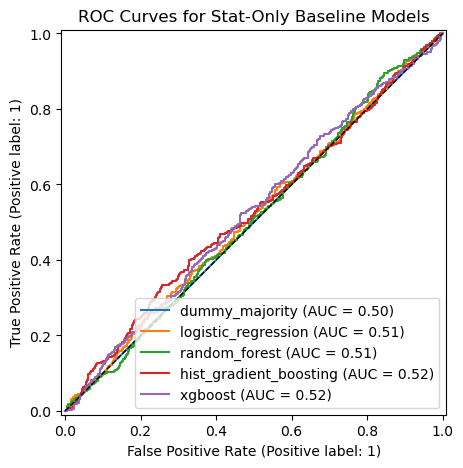

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in fitted_models.items():
    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_title("ROC Curves for Stat-Only Baseline Models")
plt.show()

Best model: xgboost
              precision    recall  f1-score   support

    p1_loses       0.54      0.62      0.57       623
     p1_wins       0.51      0.42      0.46       577

    accuracy                           0.52      1200
   macro avg       0.52      0.52      0.52      1200
weighted avg       0.52      0.52      0.52      1200



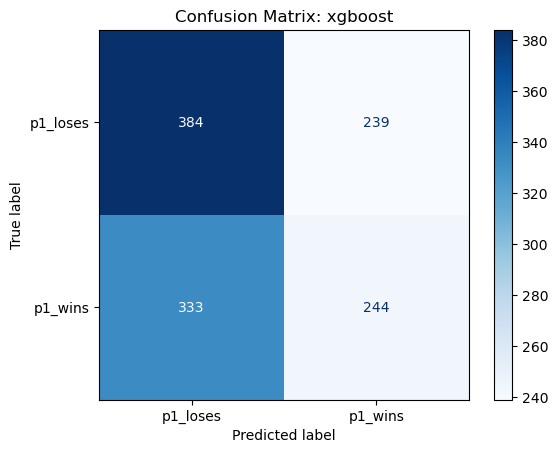

In [8]:
best_model_name = results_df.iloc[0]["name"]
best_model = fitted_models[best_model_name]

pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print(classification_report(y_test, pred, target_names=["p1_loses", "p1_wins"]))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=["p1_loses", "p1_wins"],
    cmap="Blues",
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## Feature Importance

For logistic regression, positive coefficients mean the feature pushes prediction toward p1 winning.
For tree models, feature importance is directional only in the sense of usefulness, not whether high values help p1.

,feature,coef,abs_coef
48,diff_spd_rank_4,0.101744,0.101744
47,diff_spd_rank_3,-0.098957,0.098957
36,diff_def_rank_4,-0.091635,0.091635
53,diff_spe_rank_3,0.080386,0.080386
23,diff_hp_rank_3,0.069243,0.069243
37,diff_def_rank_5,0.061499,0.061499
52,diff_spe_rank_2,-0.052119,0.052119
35,diff_def_rank_3,0.051405,0.051405
24,diff_hp_rank_4,-0.041566,0.041566
38,diff_def_rank_6,-0.032097,0.032097


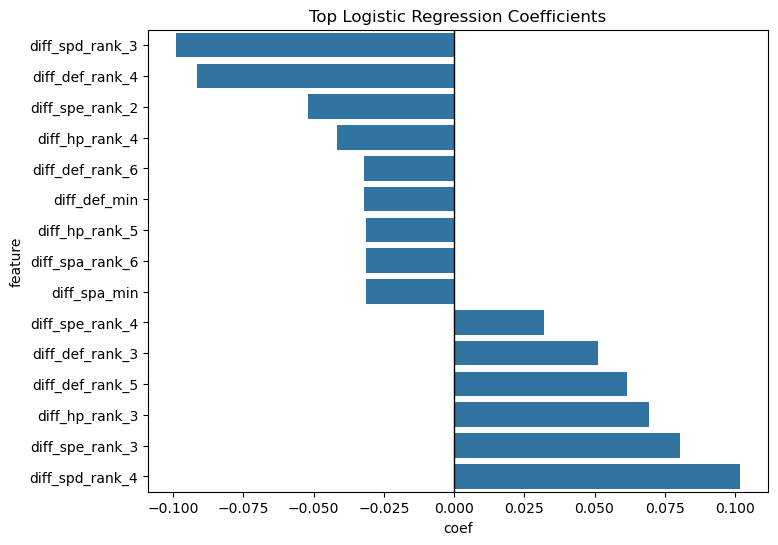

In [9]:
logreg = fitted_models.get("logistic_regression")

if logreg is not None:
    logreg_coef = pd.DataFrame({
        "feature": diff_features,
        "coef": logreg.named_steps["model"].coef_[0],
    })
    logreg_coef["abs_coef"] = logreg_coef["coef"].abs()

    display(logreg_coef.sort_values("abs_coef", ascending=False).head(20))

    plt.figure(figsize=(8, 6))
    top_coef = logreg_coef.sort_values("abs_coef", ascending=False).head(15).sort_values("coef")
    sns.barplot(data=top_coef, x="coef", y="feature")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Top Logistic Regression Coefficients")
    plt.show()

,feature,importance
20,diff_bst_max,0.021924
18,diff_bst_mean,0.020038
19,diff_bst_min,0.019817
6,diff_def_mean,0.019661
31,diff_atk_rank_5,0.019558
53,diff_spe_rank_3,0.019409
42,diff_spa_rank_4,0.019304
34,diff_def_rank_2,0.019063
9,diff_spa_mean,0.018762
41,diff_spa_rank_3,0.018736


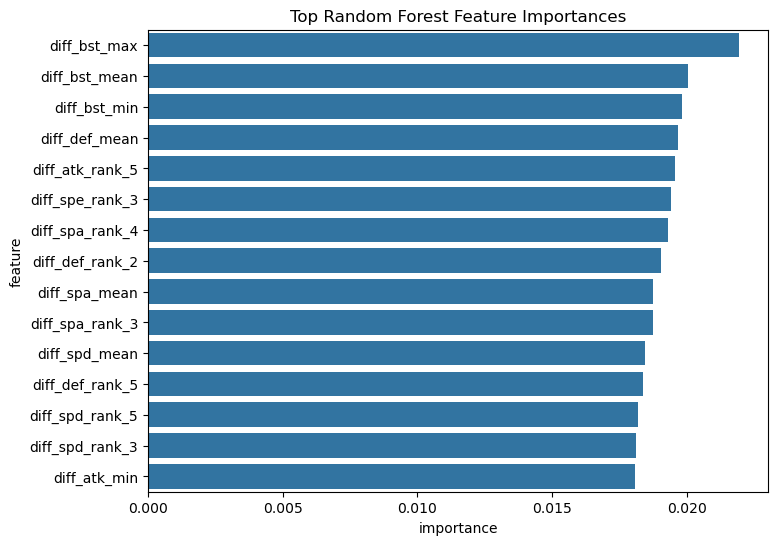

In [10]:
rf = fitted_models.get("random_forest")

if rf is not None:
    rf_importance = pd.DataFrame({
        "feature": diff_features,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(rf_importance.head(20))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=rf_importance.head(15), x="importance", y="feature")
    plt.title("Top Random Forest Feature Importances")
    plt.show()